## Session 1: LLM Parallel Workflows

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model = "gpt-5.4-mini-2026-03-17" , temperature = 0)
# model = ChatOpenAI(
#     model="openai/gpt-5.4-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
#     temperature=0,
# )

In [4]:
class EvaluationSchema(BaseModel):

    feedback: str = Field(description='Detailed feedbackfor the essay')
    score: int = Field(description='Score out of 10', ge=0, le=10)

In [6]:
structured_model = model.with_structured_output(EvaluationSchema)

In [7]:
essay = """
The Rise of AI-Based Drones in Warfare

Artificial intelligence has changed many industries, but few shifts are as consequential as the rise of AI-based drones in modern warfare. Unmanned aerial vehicles were once remote-controlled tools used mainly for surveillance. Today they are becoming faster, cheaper, more autonomous, and more decisive on the battlefield. From reconnaissance and targeting to swarm attacks and logistics, AI-enabled drones are reshaping how wars are planned, fought, and even deterred. This transformation is not only technological. It is also strategic, ethical, and political, because it changes the relationship between humans, machines, and the use of force.

The first generation of military drones was valuable mainly because it removed a pilot from danger. Operators could watch a battlefield from thousands of miles away, gather intelligence, and in some cases strike a target without risking an aircraft crew. Those systems still depended heavily on human control, stable communications, and relatively simple software. AI has pushed drones far beyond that model. Computer vision now helps a drone identify vehicles, buildings, and people. Navigation algorithms allow it to fly in GPS-denied environments. Decision-support systems can recommend targets, predict enemy movement, and coordinate multiple aircraft at once. In some experimental and battlefield settings, drones can already select routes, avoid obstacles, and continue a mission even when communication with a human operator is interrupted.

Recent conflicts have made this shift impossible to ignore. Cheap commercial drones, once associated with photography and hobby flying, have been adapted for military use at extraordinary scale. Armed forces and irregular groups alike have used them to spot artillery targets, drop munitions, and overwhelm air defenses. The important change is not only that drones are present, but that they are becoming smarter. AI can help a drone distinguish a tank from a civilian truck, fly low to avoid radar, or operate as part of a swarm. A swarm is especially significant because it multiplies force. Instead of one expensive aircraft performing one mission, dozens or hundreds of smaller drones can share information, divide tasks, and attack from many directions. This makes traditional air-defense systems, which were designed to stop a smaller number of high-value targets, much harder to use effectively.

There are several reasons this technology is spreading so quickly. First, the cost of sensors, processors, and commercial drone hardware has fallen sharply. Second, machine-learning models have become far better at perception and pattern recognition. Third, modern wars reward speed, persistence, and information. A drone that can watch a position for hours, update a targeting map in real time, and strike with little warning gives a military a major advantage. Fourth, AI reduces the need for highly trained operators in every role. That does not eliminate human involvement, but it does allow smaller teams to manage larger fleets. For countries with limited air forces, AI drones offer a way to contest the skies without building a traditional fleet of fighter jets.

The strategic consequences are already visible. Air superiority is no longer only about expensive manned aircraft. It is also about who can field, replace, and coordinate unmanned systems more effectively. Intelligence, once gathered by satellites and special missions, can now come from a dense network of flying sensors. The tempo of combat is increasing because machines can detect and respond faster than human staffs alone. Attribution and escalation are also becoming more complicated. If an autonomous or semi-autonomous drone strikes the wrong target, it may be unclear whether the error came from a human order, a software failure, a spoofed signal, or a biased model. That uncertainty can make crises harder to control.

The same qualities that make AI drones attractive also make them dangerous. Autonomy raises the risk that a machine will misidentify a target, especially in crowded or civilian environments. Training data can be incomplete, outdated, or biased, and battlefield conditions are often messy in ways that laboratory tests do not capture. Electronic warfare can jam, spoof, or hijack drones, turning a smart weapon into a liability. There is also a proliferation problem. Because many of the underlying components are commercial, the barrier to entry is lower than it was for earlier generations of military aviation. That means advanced drone capabilities may spread not only to major powers, but also to smaller states and non-state groups.

Ethical and legal questions follow close behind. International humanitarian law requires distinction, proportionality, and accountability. Those principles become harder to apply when a machine participates in life-and-death decisions. Even if a human remains “in the loop,” the speed of AI systems can leave that human with too little time to make a meaningful judgment. If a human is only “on the loop,” supervising many drones at once, responsibility may become blurred. Fully autonomous lethal systems raise an even sharper concern: should a machine ever be allowed to select and engage a human target without real-time human approval? Many governments, researchers, and civil-society groups argue that meaningful human control must be preserved. Others claim that autonomous systems could eventually be more precise than exhausted or frightened soldiers. The debate is unfinished, but it is no longer theoretical.

There is also a broader political effect. AI drones can make the use of force seem cleaner and less costly to the side that deploys them. When a country does not risk its own pilots, leaders may find it easier to launch strikes, expand missions, or remain in a conflict. That can lower the political threshold for war even as the humanitarian costs on the ground remain high. At the same time, societies targeted by constant drone surveillance and strikes may experience fear, radicalization, and long-term instability. Technology that appears precise from a command center can still feel arbitrary and oppressive to the people living under it.

The rise of AI-based drones does not mean that human judgment has become irrelevant. In fact, the opposite is true. The more powerful these systems become, the more important it is to design rules, safeguards, and command structures around them. Militaries will need robust testing, fail-safes, and clear limits on autonomy. Policymakers will need export controls, transparency standards, and international discussions about acceptable use. Engineers will need to treat reliability, bias, and security as core design problems rather than afterthoughts. And the public will need a clearer understanding of what these systems can and cannot do, because the gap between marketing claims and battlefield reality is often wide.

In the coming years, AI drones are likely to become more autonomous, more collaborative, and more deeply integrated with other systems such as satellites, ground robots, and cyber tools. Some will remain reconnaissance platforms. Others will be used for strike, electronic warfare, logistics, and even deception. The countries that adapt fastest will gain a military edge, but they will also face new risks of accident, escalation, and moral injury. The central question is not whether AI drones will shape warfare. They already do. The real question is whether governments and societies can govern that power before it outruns human control. If they succeed, these systems may reduce some forms of risk and improve situational awareness. If they fail, warfare could become faster, cheaper, and easier to start, while remaining just as destructive for the people caught beneath the sky.
"""

In [9]:
prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}'
structured_model.invoke(prompt)

EvaluationSchema(feedback="The essay is strong in language quality overall. It uses clear, formal, and polished academic prose with a well-controlled tone. The structure is logical, the paragraphing is effective, and transitions between ideas are smooth. Vocabulary is precise and appropriately sophisticated, especially in phrases like 'decision-support systems,' 'GPS-denied environments,' and 'meaningful human control.' Sentence variety is also good, with a mix of simple, compound, and complex sentences that keep the writing readable and engaging.\n\nThere are only minor issues. In a few places, the language becomes somewhat dense or repetitive in its use of abstract nouns such as 'consequences,' 'strategic,' 'ethical,' and 'political.' Some sentences could be tightened for greater punch, and a few ideas are restated in slightly different wording. However, these are stylistic rather than grammatical problems. Grammar, punctuation, and mechanics are consistently strong, with no major er

In [11]:
class EssayFeedbackState(TypedDict):

    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

In [12]:
def evaluate_language(state: EssayFeedbackState):

    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'language_feedback': output.feedback, 'individual_scores': [output.score]}

In [13]:
def evaluate_analysis(state: EssayFeedbackState):

    prompt = f'Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}

In [14]:
def evaluate_thought(state: EssayFeedbackState):

    prompt = f'Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'clarity_feedback': output.feedback, 'individual_scores': [output.score]}

In [15]:
def final_evaluation(state: EssayFeedbackState):

    # summary feedback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
    overall_feedback = model.invoke(prompt).content

    # avg calculate
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

In [16]:
graph = StateGraph(EssayFeedbackState)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

# edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()

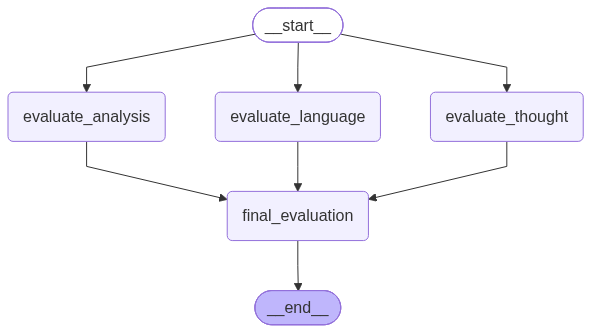

In [17]:
workflow

In [18]:
intial_state = {
    'essay': essay
}

workflow.invoke(intial_state)

{'essay': '\nThe Rise of AI-Based Drones in Warfare\n\nArtificial intelligence has changed many industries, but few shifts are as consequential as the rise of AI-based drones in modern warfare. Unmanned aerial vehicles were once remote-controlled tools used mainly for surveillance. Today they are becoming faster, cheaper, more autonomous, and more decisive on the battlefield. From reconnaissance and targeting to swarm attacks and logistics, AI-enabled drones are reshaping how wars are planned, fought, and even deterred. This transformation is not only technological. It is also strategic, ethical, and political, because it changes the relationship between humans, machines, and the use of force.\n\nThe first generation of military drones was valuable mainly because it removed a pilot from danger. Operators could watch a battlefield from thousands of miles away, gather intelligence, and in some cases strike a target without risking an aircraft crew. Those systems still depended heavily on

In [19]:
essay2 = """
Rise AI drone in war

Nowdays many countrys using the AI drone  doing war. Before time the drone like flying camera in sky and one guy he sit very far and he control with remote. But now drone become more smart and it can thinking little by itself. This is very big changing in army and in world also becouse war is not same like old days.

First the drone is usefull becouse soldier is not needing to sit inside plane. Pilot he can stay in room and looking screen and fly drone. This is more safer for him. But that drone still is needing human all time. If internet or radio is cut then drone is get confuse and maybe it falling down. After AI is come, drone start seeing things by camera and computer. It can finding tank and house and road and maybe peoples also. It can fly even GPS is not working. Some drone even decide where it going and how not hitting tree or building. This is looking like science movie but now it is happen.

In recent war we seeing so many cheap drone. Some drone is just normal shop drone but army they put bomb on it or they use for watching enemys. AI is make this drone more danger becouse it can find target more fastly. Also there is swarm. Swarm meaning many many drone flying together like bees. They sharing informations and attack from many side. Old air defence is make for stop few big plane, not for stop 200 small drone coming same time. So this is big problem for defence.

Why this tecnology is grow so fast? Becouse drone is cheap now. Computer chip also cheap. AI model is more better for seeing picture. Also war is needing speed and informations. If one drone can sitting in sky long time and tell army where enemy is, this is very usefull. Also not every country is having big air force. So they buying drone and put AI and they can fighting in sky without making jet plane. This is why small country also start using.

But this thing is also very danger. Sometimes AI is making mistake. It can thinking civilan car is army car. Training data is not always good and war place is very mess. Enemy can also jam the drone or hacking it and then you own drone become problem. Also many companys selling drone parts in market so bad groups also can buying and use. So not only big army is having this power.

There is also moral problem. Who is responsable if drone is kill wrong person? Is it soldier or programer or general or the machine? Law of war is saying you must not attack civilan and you must careful. But if machine is deciding too fast, human cannot thinking proper. Some peoples saying machine should never kill human by itself. Other peoples saying maybe machine is more accurate then tired soldier. This debate is still going and nobody is fully agree.

Another problem is politic. If country is not lose own pilot, leader maybe more easy for start war. They thinking it is clean war becouse only machine is flying. But on ground peoples still dying and they feeling fear all time becouse drone is always in sky. So war become more easy for start but still very bad for normal peoples.

I think AI drone will become more in future. They will working with satelite and robot on ground also. Country who learn this fast will become strong. But they must making rule. Human should still control important decission. Testing should be proper. Engineer should make sure AI is not biase and not easy for hack. Public also should understand this, becouse company sometimes saying drone is perfect but in real war it is not perfect.

So conclusion is AI drone already change the war. Question is not if it will come, it already come. Question is can human control it or it will go out of control. If we make good rule maybe it help army see better and reduce some risk. If we not make rule then war become more cheap more fast and more easy, but peoples under the sky still suffer same.
"""

In [20]:
intial_state = {
    'essay': essay2
}

workflow.invoke(intial_state)

{'essay': '\nRise AI drone in war\n\nNowdays many countrys using the AI drone  doing war. Before time the drone like flying camera in sky and one guy he sit very far and he control with remote. But now drone become more smart and it can thinking little by itself. This is very big changing in army and in world also becouse war is not same like old days.\n\nFirst the drone is usefull becouse soldier is not needing to sit inside plane. Pilot he can stay in room and looking screen and fly drone. This is more safer for him. But that drone still is needing human all time. If internet or radio is cut then drone is get confuse and maybe it falling down. After AI is come, drone start seeing things by camera and computer. It can finding tank and house and road and maybe peoples also. It can fly even GPS is not working. Some drone even decide where it going and how not hitting tree or building. This is looking like science movie but now it is happen.\n\nIn recent war we seeing so many cheap drone

## Quick Task: Resume Reviewer (15 mins)

Same pattern as the essay graph: **3 LLM evaluators in parallel, then a final summary node**.

Build a workflow that reviews a `resume` on:

1. **Skills**
2. **Experience**
3. **Communication**

Each evaluator returns feedback + a score out of 10. The final node summarizes the three feedbacks and computes `avg_score`.

**Hints**
- Reuse `EvaluationSchema` and `structured_model` from above
- State fields: `resume`, `skills_feedback`, `experience_feedback`, `communication_feedback`, `overall_feedback`, `individual_scores`, `avg_score`
- `individual_scores` must be `Annotated[list[int], operator.add]` so parallel scores merge instead of colliding
- Each parallel node should return only what it updates, e.g. `{'skills_feedback': ..., 'individual_scores': [output.score]}`
- Edges: `START` → all 3 evaluators → `final_evaluation` → `END`

Fill in the cells below.

In [ ]:
# define state
class ResumeFeedbackState(TypedDict):
    ...

In [ ]:
# node 1: evaluate skills
def evaluate_skills(state: ResumeFeedbackState):
    ...

In [ ]:
# node 2: evaluate experience
def evaluate_experience(state: ResumeFeedbackState):
    ...

In [ ]:
# node 3: evaluate communication
def evaluate_communication(state: ResumeFeedbackState):
    ...

In [ ]:
# node 4: summarize the 3 feedbacks and compute avg_score
def final_evaluation(state: ResumeFeedbackState):
    ...

In [ ]:
# define your graph, add nodes + edges, compile
# START → evaluate_skills / evaluate_experience / evaluate_communication → final_evaluation → END

In [ ]:
workflow

In [ ]:
resume = """
Rahul Sharma
Data Scientist | Bengaluru

Skills: Python, SQL, pandas. Some exposure to machine learning.

Experience:
- 1 year at a startup, cleaned Excel sheets and built a few dashboards
- Internship: predicted house prices with linear regression (accuracy not mentioned)

Projects:
- Customer churn notebook on Kaggle, no deployment
- Chatbot using OpenAI API, hardcoded prompts

Education: B.Tech Computer Science, 2023
"""

In [ ]:
# execute the graph
# initial_state = {'resume': resume}